# EDA for Merged eaglei

This notebook contains modified versions of the competition-provided scripts for doing basic EDA with the merged eaglei data (i.e., all years of eaglei data in a single file)

## Power Outage Data

This uses the eaglei data along with predictors from other sources.

The file is the `eaglei_outages_with_county_info.parquet` file, generated by the `resample_eaglei...` script. This data set includes a 6-hour cadence subset of the power outage data from 2014-2023 (we will need to manually exclude data from 2022-2023 for our test set).

In [7]:
import pandas as pd

# Load the dataset eaglei_outages_with_county_info.parquet
df_power = pd.read_parquet('../Data/Merged_Data/eaglei_outages_with_county_info.parquet')

# Restrict df_power to years before 2022
df_power = df_power[df_power['YEAR'] < 2022]

Below is a plot of aggregate power outages for all states and all data points in the data set. 

This is adapted from the utils file to use the already-loaded df_power dataframe.

It looks like Florida leads the nation!

In [8]:
import plotly.express as px

#Set the beginning and end of the time interval
begin ='2014-01-01 00:00:00'
end='2021-12-31 00:00:00'

#Convert start_time to datetime object
start_time = datetime.strptime(begin, '%Y-%m-%d %H:%M:%S')
end_time = datetime.strptime(end, '%Y-%m-%d %H:%M:%S')

grouped = df_power[(df_power['datetime'] >= start_time) & (df_power['datetime'] <= end_time)].groupby('STUSPS').agg({'customers_out': 'sum'}).reset_index()
grouped['customers_out'] = grouped['customers_out'] / 4 #Used to be 96 for 15-minute cadence
title = "Power Outages by State"
location_col = 'state'

# Normalize colormap to the data range
max_outages = grouped['customers_out'].max()
min_outages = grouped['customers_out'].min()


# Create choropleth map
fig = px.choropleth(
    grouped,
    locations='STUSPS',
    locationmode='USA-states',
    color='customers_out',
    color_continuous_scale="OrRd",
    scope="usa",
    range_color=(min_outages, max_outages),  # Fix normalization
    title=f"{title} ({start_time.strftime('%Y-%m-%d')} to {end_time.strftime('%Y-%m-%d')})",
    labels={'customers_out': 'customers.day'}
)

# Add hover info to display total numbers
fig.update_traces(
    hovertemplate='<b>%{location}</b><br>Total Outage: %{z}<extra></extra>'
)

fig.update_geos(showcoastlines=True, coastlinecolor="Black")

fig.update_layout(
    geo=dict(
        lakecolor="lightblue",
        showlakes=True
    ),
    title_x=0.4,  # Center the title
    margin=dict(l=0, r=0, t=50, b=0),  # Minimize space between colorbar and map figure
    width=1000, height=600,  # Set figure size to (10, 6)
    title_font=dict(size=20, family='Arial, bold'),  # Set figure title font size and make it bold
    font=dict(size=14)  # Set default font size for the figure
)
    
fig.show()

In [9]:
#List all values of the Subregion variable
df_power['Subregion'].unique()

array(['SRSO', 'SRTV', 'NWPP', 'AZNM', 'SRMV', 'SPSO', 'CAMX', 'RMPA',
       'RFCE', 'FRCC', 'SRMW', 'RFCW', 'MROW', 'SPNO', 'NEWE', None,
       'RFCM', 'MROE', 'NYUP', 'NYCW', 'NYLI', 'SRVC', 'ERCT'],
      dtype=object)

I'll first be focusing on the NewEngland regional grid for the year 2020 to keep things simple-ish.

In 2020, parts of Maine experienced several significant weather-related events leading to power outages. ChatGPT reports (citing BangorDailyNews.com):

- April 2020 Snowstorm: A snowstorm dropped a foot of snow in many areas, leaving more than 250,000 Mainers without power for two days. 
- August 2020 Tropical Storm Isaias: This storm resulted in power outages affecting more than 70,000 residents for almost three days. 
- December 2020: "first a rain storm knocked out electrical service to more than 100,000 Mainers and then, four days later, another storm brought gusty winds and snow to much of the state, cutting power to more than 200,000 electricity customers. Some lost power for days."

Below is a plot (by county) of person-days (in millions) without power, followed by a time graph of person-days for 2019, 2020, and 2021, demonstrating the three unusual spikes corresponding to the above weather events, as well as another spike in late September/early October

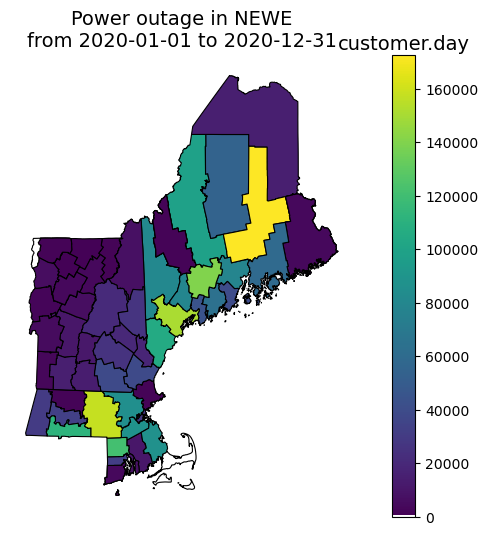

In [11]:
#Set the beginning and end of the time interval
begin ='2020-01-01 00:00:00'
end='2020-12-31 00:00:00'

#Identify the subregion and create a list of states in that subregion
Subregion = 'NEWE'
states_in_subregion = df_power[df_power['Subregion'] == Subregion]['STUSPS'].unique()

#Convert start_time to datetime object
start_time = datetime.strptime(begin, '%Y-%m-%d %H:%M:%S')
end_time = datetime.strptime(end, '%Y-%m-%d %H:%M:%S')

#Read the counties geometry file and restrict to counties to whre STUSPS is in the list states_in_subregion
counties = gpd.read_file('../Data/County_Shapefiles/cb_2023_us_county_500k.zip')
counties = counties[counties['STUSPS'].isin(states_in_subregion)]

# Filter data based on time range and state
grouped = df_power[(df_power['datetime'] >= start_time) & (df_power['datetime'] <= end_time) & (df_power['Subregion'] == Subregion)].groupby(['NAME','fips_code']).agg({'customers_out': 'sum'}).reset_index()
grouped['customers_out'] = grouped['customers_out'] / 4 #Used to be 96 for 15-minute cadence

# Merge the counties with aggregated data
grouped['fips_code'] = grouped['fips_code'].astype(str)  # Ensure FIPS codes are strings
counties = counties.merge(grouped, left_on='NAME', right_on='NAME', how='left')

# Fill missing values with zero so we display it in white color
counties['customers_out'] = counties['customers_out'].fillna(0) 


# Create a custom colormap
viridis_cmap = plt.cm.viridis  # Base colormap
colors = viridis_cmap(np.linspace(0, 1, 256))  # Extract colors from viridis
colors[0] = np.array([1, 1, 1, 1])  # Set the first color (for zero values) to white
custom_cmap = ListedColormap(colors)

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
county_plot = counties.plot(column='customers_out',  # Data to visualize
                            cmap=custom_cmap,  # Colormap
                            linewidth=0.8,
                            ax=ax,
                            edgecolor='black',
                            legend=False,  # Disable automatic colorbar
                            norm=Normalize(vmin=0, vmax=counties['customers_out'].max())  # Normalize scale
                            )

# Add colorbar and set its title
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=0, vmax=counties['customers_out'].max()))
sm._A = []  # Dummy array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label('Number of Customers Out', fontsize=12, labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.set_xlabel('customer.day', fontsize=14)

# Remove the vertical label
cbar.ax.set_ylabel('')

# Customize the plot
title = f"Power outage in {Subregion}\nfrom {start_time.strftime('%Y-%m-%d')} to {end_time.strftime('%Y-%m-%d')}"
ax.set_title(title, fontsize=14)
ax.axis('off')  # Turn off the axis
plt.show()

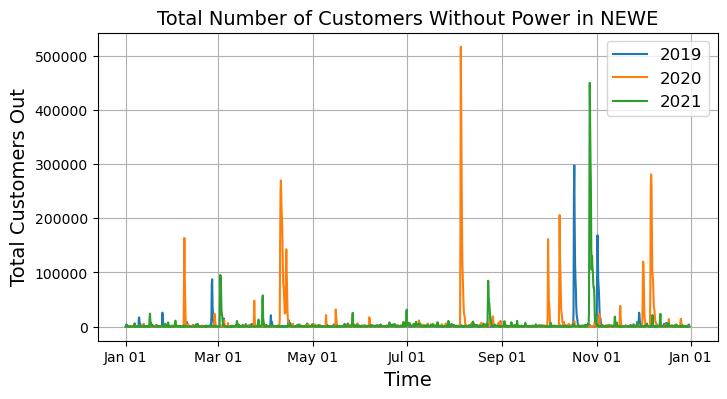

In [12]:
years = ['2019', '2020', '2021']

#Identify the subregion and create a list of states in that subregion
Subregion = 'NEWE'
states_in_subregion = df_power[df_power['Subregion'] == Subregion]['STUSPS'].unique()
    
plt.figure(figsize=(8, 4))
df_power.dropna(subset=['customers_out'], inplace=True)

# Loop through each year and plot the data
for year in years:

    # Filter df_power for the year and subregion
    df_subregion = df_power[(df_power['YEAR'] == int(year)) & (df_power['Subregion'] == Subregion)].copy()
    
    # Remove the year from 'run_start_time' to stack plots on top of each other
    df_subregion['datetime'] = df_subregion['datetime'].apply(lambda x: x.replace(year=2000))
    
    # Group by 'run_start_time' and sum the 'customers_out' for each timestamp
    df_subregion_grouped = df_subregion.groupby('datetime')['customers_out'].sum().reset_index()
    
    # Plot the time history of total customers out
    plt.plot(df_subregion_grouped['datetime'], df_subregion_grouped['customers_out'], linestyle='-', label=year)
    
plt.title(f'Total Number of Customers Without Power in {Subregion}', fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Total Customers Out', fontsize=14)
plt.grid(True)
# Format x-axis to show only month and day, remove year
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
plt.legend(fontsize=12)  # Add legend with specified font size
plt.show()

It would also be interesting to look at a couple other factors that might be related to power outages. Let's start by making a map of the Pct_Buried_Lines variable

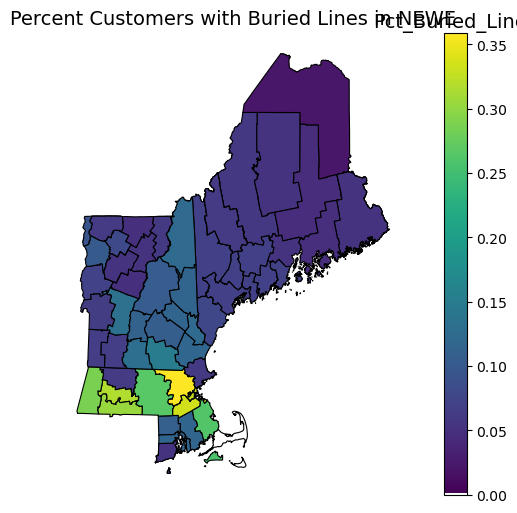

In [13]:
#Identify the subregion and create a list of states in that subregion
Subregion = 'NEWE'
states_in_subregion = df_power[df_power['Subregion'] == Subregion]['STUSPS'].unique()

#Read the counties geometry file and restrict to counties to whre STUSPS is in the list states_in_subregion
counties = gpd.read_file('../Data/County_Shapefiles/cb_2023_us_county_500k.zip')
counties = counties[counties['STUSPS'].isin(states_in_subregion)]

# Filter data based on time range and state
grouped = df_power[(df_power['Subregion'] == Subregion)].groupby(['NAME','fips_code']).agg({'Pct_Buried_Lines': 'max'}).reset_index()

# Merge the counties with aggregated data
grouped['fips_code'] = grouped['fips_code'].astype(str)  # Ensure FIPS codes are strings
counties = counties.merge(grouped, left_on='NAME', right_on='NAME', how='left')

# Fill missing values with zero so we display it in white color
counties['Pct_Buried_Lines'] = counties['Pct_Buried_Lines'].fillna(0) 


# Create a custom colormap
viridis_cmap = plt.cm.viridis  # Base colormap
colors = viridis_cmap(np.linspace(0, 1, 256))  # Extract colors from viridis
colors[0] = np.array([1, 1, 1, 1])  # Set the first color (for zero values) to white
custom_cmap = ListedColormap(colors)

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
county_plot = counties.plot(column='Pct_Buried_Lines',  # Data to visualize
                            cmap=custom_cmap,  # Colormap
                            linewidth=0.8,
                            ax=ax,
                            edgecolor='black',
                            legend=False,  # Disable automatic colorbar
                            norm=Normalize(vmin=0, vmax=counties['Pct_Buried_Lines'].max())  # Normalize scale
                            )

# Add colorbar and set its title
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=0, vmax=counties['Pct_Buried_Lines'].max()))
sm._A = []  # Dummy array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label('Number of Customers Out', fontsize=12, labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.set_xlabel('Pct_Buried_Lines', fontsize=14)

# Remove the vertical label
cbar.ax.set_ylabel('')

# Customize the plot
title = f"Percent Customers with Buried Lines in {Subregion}"
ax.set_title(title, fontsize=14)
ax.axis('off')  # Turn off the axis
plt.show()

Below is a plot comparing New England (NEWE) to NY City (NYCW) and NY Upstate (NYUP) for 2020.

It looks like the NEWE had more customers without power... although we should probably also consider other factors like buried power lines.

The mid-August spike appears to have occured in all three subregions. Seems like this was probably from the tropical storm that moved through many counties.

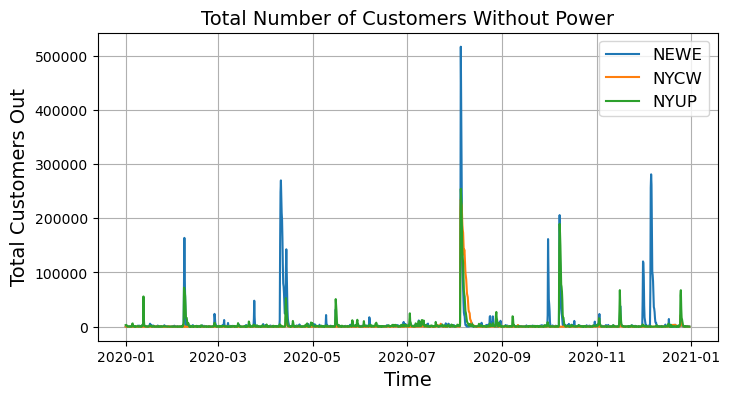

In [14]:
#Set the beginning and end of the time interval
begin ='2020-01-01 00:00:00'
end='2020-12-31 00:00:00'
subregions = ['NEWE', 'NYCW', 'NYUP']

#Convert begin and end to datetime object
start_time = datetime.strptime(begin, '%Y-%m-%d %H:%M:%S')
end_time = datetime.strptime(end, '%Y-%m-%d %H:%M:%S')


#df_power['datetime'] = pd.to_datetime(df_power['datetime'])
#df_power.dropna(subset=['customers_out'],inplace=True)

plt.figure(figsize=(8, 4))

# Loop through each subregion and plot the data
for subregion in subregions:
    # Restrict df_power to times between start_time and end_time
    df_subregion = df_power[(df_power['datetime'] >= start_time) & (df_power['datetime'] <= end_time) & (df_power['Subregion'] == subregion)]

    # Group by 'run_start_time' and sum the 'customers_out' for each timestamp
    df_subregion_grouped = df_subregion.groupby('datetime')['customers_out'].sum().reset_index()
    
    # Plot the time history of total customers out
    plt.plot(df_subregion_grouped['datetime'], df_subregion_grouped['customers_out'], linestyle='-', label=subregion)

plt.title('Total Number of Customers Without Power', fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Total Customers Out', fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)  # Add legend with specified font size
plt.show()

### NOAA's Storm Events Dataset

Below, we load `StormEvents_2014_2024.csv` as a pandas DataFrame. This DataFrame provides extensive details about storm events, including their type, location, time, and magnitude. For example, you can view all 55 types of storms in the U.S. from 2014 to 2024 by examining the `EVENT_TYPE` column, as shown below.

In [30]:
df_events = pd.read_parquet("../Data/NOAA_Cleaned_Data/NOAA_Cleaned_ExplodedFIPS.parquet")

In [38]:
df_events

,EVENT_TYPE,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,...,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,STATE_ABBREV,FIPS,Number_of_FIPS,total_duration_min,total_duration_perfips_min,Subregion,EVENT_CATEGORY
0,Heavy Snow,2014-02-18 10:00:00,EST-5,2014-02-18 20:00:00,0,0,0,0,0.00K,0.00K,...,NaN,Low pressure developing south of Long Island a...,Eight to twelve inches of snow fell across eas...,NH,33011.0,1,600.0,600.0,NEWE,SnowIce
1,Flood,2014-03-30 08:31:00,EST-5,2014-03-30 09:31:00,0,0,0,0,35.00K,0.00K,...,-71.3469,A stacked low pressure system passed south and...,Boston Road was closed near Brian Road due to ...,MA,25017.0,1,60.0,60.0,NEWE,Other
2,Hail,2014-04-27 23:06:00,CST-6,2014-04-27 23:06:00,0,0,0,0,0.00K,0.00K,...,-92.6600,A powerful storm system and a dry line produce...,None,MO,29067.0,1,0.0,0.0,SRMW,Storm
3,Thunderstorm Wind,2014-04-27 23:03:00,CST-6,2014-04-27 23:03:00,0,0,0,0,10.00K,0.00K,...,-92.6600,A powerful storm system and a dry line produce...,Several power poles snapped and trees blown down.,MO,29067.0,1,0.0,0.0,SRMW,Wind
4,High Wind,2014-02-15 13:00:00,PST-8,2014-02-15 21:00:00,0,0,0,0,0.00K,0.00K,...,NaN,A strong cold front produced strong winds for ...,Two stations measured strong wind gusts in the...,WA,53059.0,1,480.0,480.0,NWPP,Wind
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528729,Flash Flood,2021-07-25 19:00:00,MST-7,2021-07-25 21:00:00,0,0,0,0,0.00K,0.00K,...,-105.2811,Another active period across southern Colorado...,Extensive road damage was observed. A 7 foot w...,CO,8027.0,1,120.0,120.0,RMPA,Flood
528730,Thunderstorm Wind,2021-07-09 20:59:00,MST-7,2021-07-09 21:02:00,0,0,0,0,0.00K,0.00K,...,-102.3200,Strong to severe thunderstorms were expected a...,None,CO,8099.0,1,3.0,3.0,RMPA,Wind
528731,Flash Flood,2021-07-01 20:35:00,MST-7,2021-07-01 22:35:00,0,0,0,0,0.00K,0.00K,...,-106.0093,The setup on this day supported another summer...,County roads 110 and 111 were washed out.,CO,8015.0,1,120.0,120.0,RMPA,Flood
528732,Thunderstorm Wind,2021-07-06 14:10:00,EST-5,2021-07-06 14:10:00,0,0,0,0,5.00K,0.00K,...,-76.0800,Scattered thunderstorms developed ahead of a c...,Strong thunderstorm winds snapped a large tree...,NY,36007.0,1,0.0,0.0,NYUP,Wind


In [33]:
# Restrict df_events to ears prior to 2022
df_events = df_events[df_events['BEGIN_DATE_TIME'] < '2022-01-01']

In [36]:
print("Different storm event types in the US from 2014 to 2021:")
df_events['EVENT_TYPE'].unique()

Different storm event types in the US from 2014 to 2021:


array(['Heavy Snow', 'Flood', 'Hail', 'Thunderstorm Wind', 'High Wind',
       'Winter Storm', 'Winter Weather', 'Drought', 'Ice Storm',
       'Tornado', 'Strong Wind', 'Flash Flood', 'Extreme Cold/Wind Chill',
       'Blizzard', 'Avalanche', 'Cold/Wind Chill', 'Funnel Cloud',
       'Heavy Rain', 'Frost/Freeze', 'Wildfire', 'Sleet', 'Dust Storm',
       'Freezing Fog', 'Rip Current', 'Lightning', 'Debris Flow',
       'Dense Fog', 'Astronomical Low Tide', 'High Surf', 'Dust Devil',
       'Coastal Flood', 'Lake-Effect Snow', 'Heat', 'Tropical Storm',
       'Lakeshore Flood', 'Seiche', 'Excessive Heat', 'Dense Smoke',
       'Storm Surge/Tide', 'Sneakerwave', 'Hurricane (Typhoon)',
       'Tsunami', 'Tropical Depression', 'Hurricane', 'Volcanic Ashfall'],
      dtype=object)

Rather than try to consider all the different event types individually, I'm going to try to combine them into categories. This might help facilitate seasonal identification.

In [37]:
# Create categories of event types

snowice_types = ['Heavy Snow', 'Winter Storm', 'Winter Weather', 'Ice Storm', 'Extreme Cold/Wind Chill','Blizzard', 'Avalanche', 'Cold/Wind Chill', 'Frost/Freeze','Sleet','Freezing Fog', 'Lake-Effect Snow']

flood_types = ['Flash Flood', 'Coastal Flood','Lakeshore Flood','Debris Flow']

storm_types = ['Heavy Rain','Tropical Storm','Tropical Depression','Hail','Lightning','Marine Lightning']

hurricane_types = ['Marine Hurricane/Typhoon','Hurricane','Hurricane (Typhoon)']

heat_types = ['Excessive Heat', 'Heat']

fire_types= ['Wildfire','Dense Smoke']

wind_types = ['Marine Strong Wind', 'Marine High Wind', 'High Wind', 'Strong Wind', 'Thunderstorm Wind', 'Marine Thunderstorm Wind','Tornado','Waterspout', 'Funnel Cloud']

ocean_types = ['Rip Current','Astronomical Low Tide', 'Marine Dense Fog','Marine Tropical Depression','Marine Hail','High Surf', 'Marine Tropical Storm', 'Seiche','Storm Surge/Tide', 'Tsunami', 'Sneakerwave']

other_types = ['Drought','Dust Storm', 'Dense Fog', 'Dust Devil', 'Volcanic Ashfall']

# Add a new column to df_events that recodes EVENT_TYPE into the listed categories above
df_events['EVENT_CATEGORY'] = df_events['EVENT_TYPE'].apply(lambda x: 'SnowIce' if x in snowice_types else
                                                             'Flood' if x in flood_types else
                                                             'Storm' if x in storm_types else
                                                             'Hurricane' if x in hurricane_types else
                                                             'Heat' if x in heat_types else
                                                             'Fire' if x in fire_types else
                                                             'Wind' if x in wind_types else
                                                             'Ocean' if x in ocean_types else
                                                             'Other')

/var/folders/gs/h69vjsl512b8200d29lxpgrc0000gn/T/ipykernel_22604/239175960.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Below is code (modified from utils.py) to make bar charts of various event types throughout each month

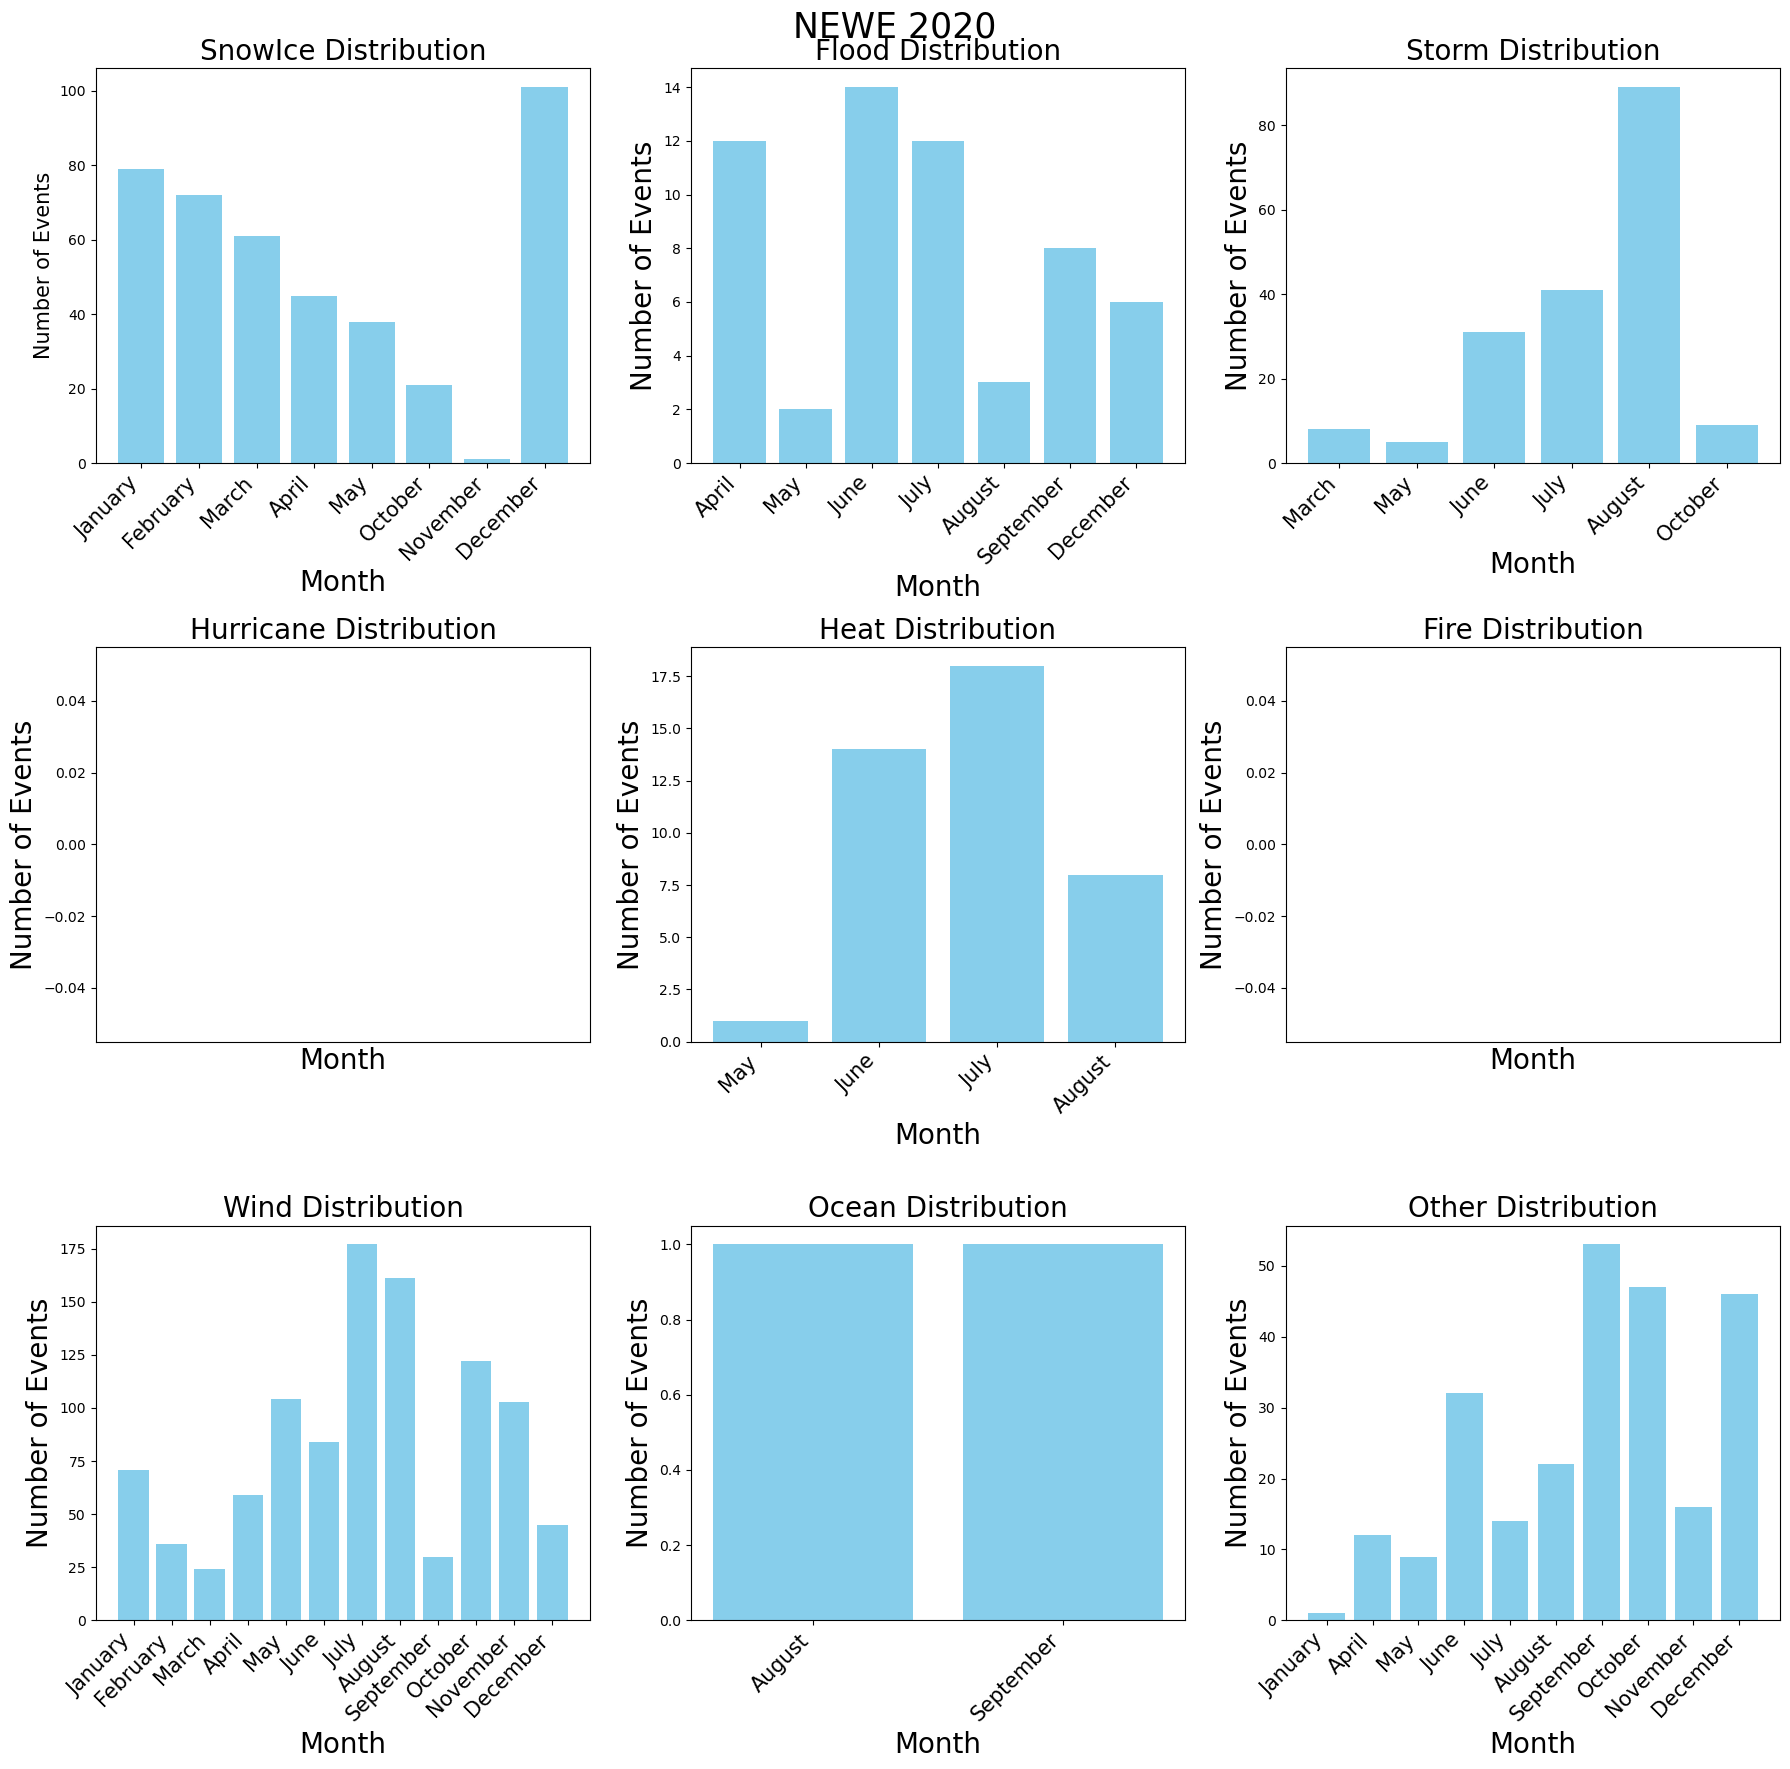

In [48]:
state='ME'
subregion = 'NEWE'
all_years = False
which_year = 2020
event_types = ['SnowIce', 'Flood', 'Storm', 'Hurricane', 'Heat', 'Fire', 'Wind', 'Ocean', 'Other']

#Make a list of all FIPS values from df_power that have a Subregion value of NEWE
fips_list = df_power[df_power['Subregion'] == subregion]['fips_code'].unique()


if all_years:
    df_subregion = df_events[df_events['FIPS'].isin(fips_list)]
    title = f"{subregion} 2014-2021"
else:
    df_subregion = df_events[(df_events['FIPS'].isin(fips_list)) & (df_events['BEGIN_DATE_TIME'].dt.year == which_year)]
#    df_subregion = df_events[(df_events['FIPS'].isin(fips_list)) & (df_events['YEAR']==which_year)]
    title = f"{subregion} {which_year}" 

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 18))

# Loop through event types and create plots
for i, event in enumerate(event_types):
    # Filter data for the specific event type
    event_data = df_subregion[df_subregion['EVENT_CATEGORY'] == event]        
    
    # Group by MONTH and count events
    monthly_data = event_data.groupby(event_data['BEGIN_DATE_TIME'].dt.month_name()).size().reset_index(name='Event Count')
#    monthly_data = event_data.groupby('MONTH_NAME').size().reset_index(name='Event Count')
    # Sort monthly_data by month
    monthly_data['MONTH_SORT'] = pd.to_datetime(monthly_data['BEGIN_DATE_TIME'], format='%B')
    monthly_data = monthly_data.sort_values(by='MONTH_SORT')

    # Plot the data in a 3x3 grid
    row = i // 3
    col = i % 3

    # Plot the data
    axes[row, col].bar(monthly_data['BEGIN_DATE_TIME'], monthly_data['Event Count'], color='skyblue')
    axes[row, col].set_title(f'{event} Distribution', fontsize=20)
    axes[row, col].set_xlabel('Month', fontsize=20)
    axes[row, col].set_ylabel('Number of Events', fontsize=20)
    
    axes[row, col].set_xticks(range(len(monthly_data['BEGIN_DATE_TIME'].unique())))
    axes[row, col].set_xticklabels(monthly_data['BEGIN_DATE_TIME'].unique(), rotation=45, ha='right', fontsize=15)

# Set common Y label
axes[0,0].set_ylabel('Number of Events', fontsize=15)

plt.suptitle(title, fontsize=25)
# Adjust layout
plt.tight_layout()
plt.show()

<br>

**Storm events severity and duration:** To understand the effects of storm events on power outages, it's crucial to consider not only the type of storm event but also its severity and duration. 

The provided notebook has code to create a new "duration" variable. But this is already created in the cleaned NOAA data file.

The histogram reveals that event durations are highly skewed, with many events having short durations. These short-duration events are likely inconsequential to power outages. However, it's important to note that depending on the type of storm event, even short-duration events can have a significant impact on power outages.

To further analyze this, we plot the event durations individually for each storm event type using a box plot. This visualization helps us understand the distribution of event durations for different types of storms and highlights the variability in their impact on power systems.

In summary, when assessing the impact of storm events on power outages, it's essential to consider not just the frequency of events but also their type, severity, and duration. These factors are critical in understanding and predicting the potential disruptions to power systems.

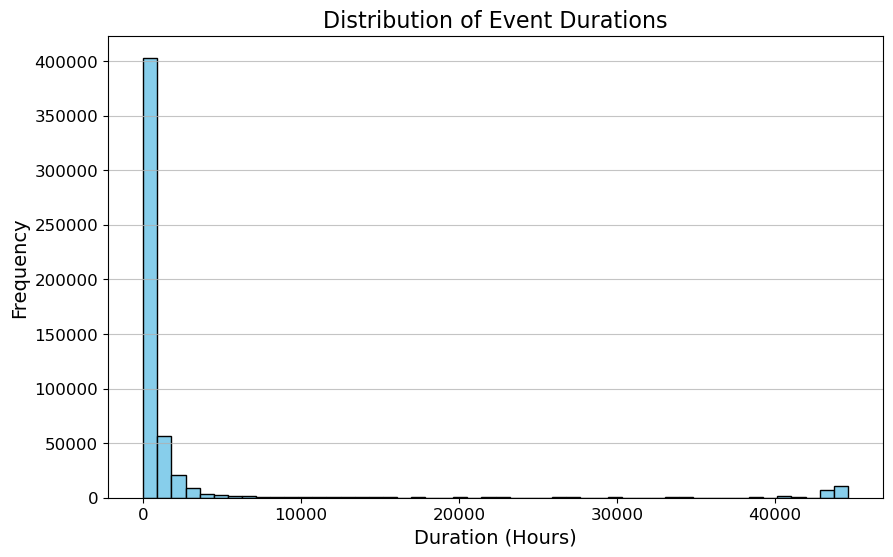

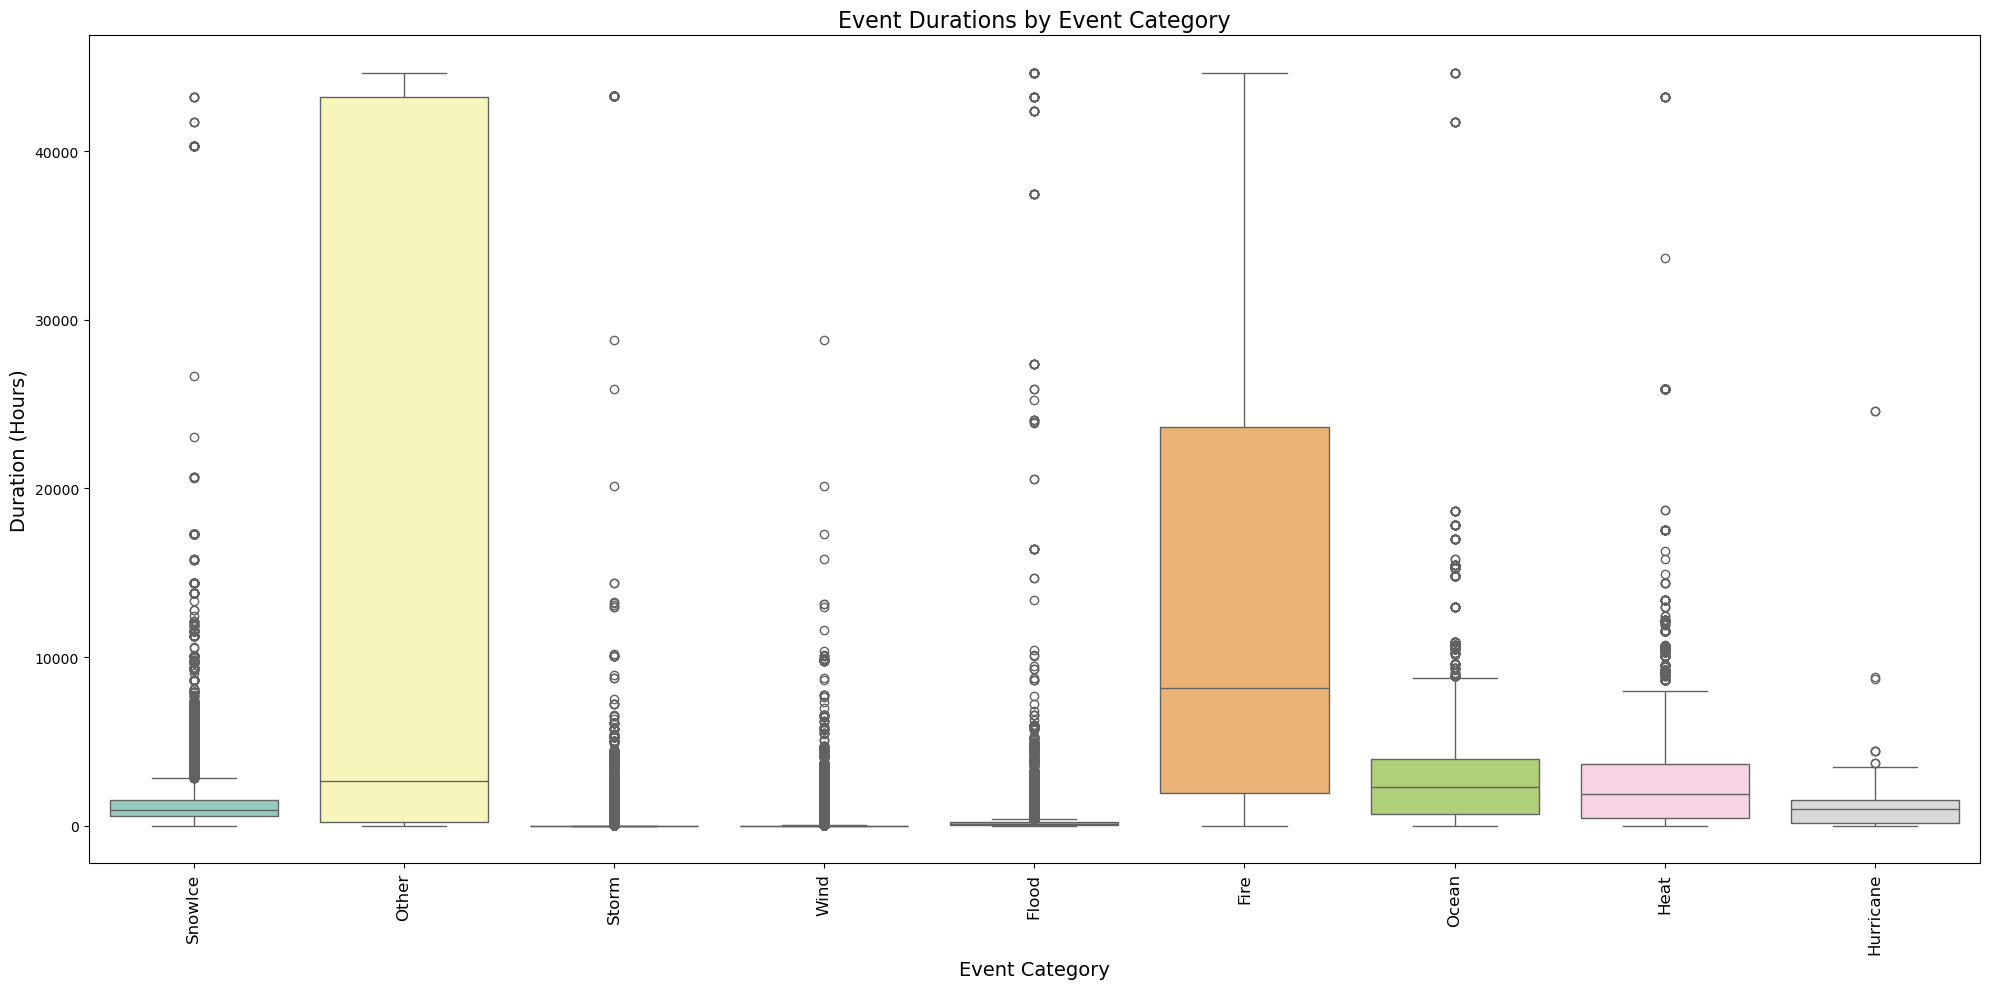

In [ ]:
import matplotlib.pyplot as plt

# Plot histogram for the total_duration_min variable in df_events
plt.figure(figsize=(10, 6))
plt.hist(df_events['total_duration_min'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Event Durations', fontsize=16)
plt.xlabel('Duration (Minutes)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# Plot boxplot for total_duration_min for every storm event
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_events, x='EVENT_CATEGORY', y='total_duration_min', showfliers=True, palette="Set3")
plt.title('Event Durations by Event Category', fontsize=16)
plt.xlabel('Event Category', fontsize=14)
plt.ylabel('Duration (Hours)', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.tight_layout()
plt.show()

## Combined Datasets: Basic Correlation Analysis

**Notes:**
- The provided workbook includes code to transform the NOAA data into a timeseries. We've already done this in the NOAA_Timeseries parquet file.
- The provided workbook also includes code to merge the NOAA timeseries with the eaglei data. We've already done this in the eaglei_noaa parquet file

In [ ]:
#Load the eaglei_noaa dataframe
eaglei_noaa = pd.read_parquet('../Data/eaglei_data/eaglei_noaa_latlon.parquet')

We'll want to restrict the data to a single county or a list of counties. Below is an example for Tompkins County, NY, and its neighboring counties, and also restrict the data to our training set (2014-2021)

In [ ]:
# Restrict eaglei_noaa to the following FIPS index values: [36109, 36011, 36097, 36015, 36107, 36023, 36099]
fips = [36109, 36011, 36097, 36015, 36107, 36023, 36099]
eaglei_noaa = eaglei_noaa.loc[fips]

#Sort eaglei_noaa by its FIPS and time indices
eaglei_noaa.sort_index(inplace=True)

#Slice eaglei_noaa to time values between 2014-01-01 and 2021-12-31
start = '2014-01-01'
end = '2021-12-31'
eaglei_noaa = eaglei_noaa.loc[(slice(None), slice(start, end), slice(None), slice(None)), :]

Next, we'll make a timeseries plot of the various event categories and customers out

In [ ]:
#List the variables in eaglei_noaa that start with event_count
event_count_columns = [col for col in eaglei_noaa.columns if col.startswith('event_count')]

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import seaborn as sns


#Restrict eaglei_noaa to FIPS index 36109
eaglei_noaa_fips = eaglei_noaa.loc[36109]

#Make a time series graph for the variables in event_count_columns using one scale, and for the customers_out variable using a different scale
fig, ax1 = plt.subplots(figsize=(15, 5))
#Plot the event_count variables
for col in event_count_columns:
    ax1.plot(eaglei_noaa_fips.index.get_level_values('time'), eaglei_noaa_fips[col], label=col)
#Plot the customers_out variable
ax2 = ax1.twinx()
ax2.plot(eaglei_noaa_fips.index.get_level_values('time'), eaglei_noaa_fips['customers_out'], label='customers_out', color='black')
#Set the title and labels
ax1.set_title('EAGLEI Event Counts and Customers Out for FIPS 36109')
ax1.set_xlabel('Time')
ax1.set_ylabel('Event Counts')
ax2.set_ylabel('Customers Out')
#Add a legend
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
#Show the plot
plt.show()

# Correlations

**Note: I haven't yet worked on updating this.

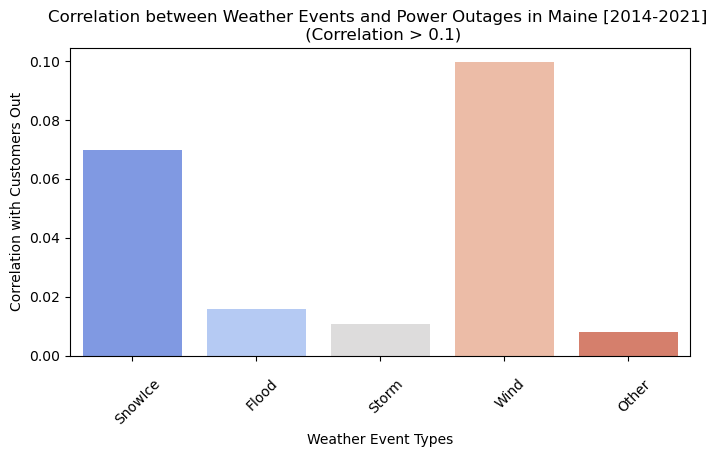

In [ ]:
#Find only columns in df_power_events_ME with "event_count" or "customers_out" in the name
event_count_columns = [col for col in eaglei_noaa_fips.columns if 'event_count' in col or col == 'customers_out']

#Remove total_event_count from event_count_columns
event_count_columns.remove('total_event_count')

correlation_with_customers_out = eaglei_noaa_fips[event_count_columns].corr()['customers_out'].drop('customers_out')

# Filter correlations higher than 0.0
filtered_correlation = correlation_with_customers_out[correlation_with_customers_out > 0.0]

corr_list = list(filtered_correlation.index)

# Remove 'event_count' from the column names for plotting
filtered_correlation.index = filtered_correlation.index.str.replace('event_count', '')

# Split two-word names into two lines
filtered_correlation.index = filtered_correlation.index.str.replace(' ', '\n')

# Plot the filtered correlation
plt.figure(figsize=(8, 4))
sns.barplot(x=filtered_correlation.index, y=filtered_correlation.values,
            hue=filtered_correlation.index, palette='coolwarm')
plt.xlabel('Weather Event Types')
plt.ylabel('Correlation with Customers Out')
plt.title('Correlation between Weather Events and Power Outages in Tompkins County [2014-2021] \n (Correlation > 0.1)')
plt.xticks(rotation=45)
plt.show()


To visually examine these correlations, we plot the time histories of power outages (`customers_out`) and event counts for the five event types mentioned earlier (Winter Storm, Cold/Wind Chill, Frost/Freeze, Ice Storm, and Extreme Cold/Wind Chill) for February 2021. The figure supports the correlation analysis discussed above. 

An interesting observation is that power outages lag behind storm events by a few days. This makes sense, as the buildup of a storm can eventually damage power infrastructure and cause outages. To further investigate this time delay between power outages and storm events, we calculate their correlation at different time shifts using the cross-correlation function (`ccf`) from the `statsmodels` library. 

We focus specifically on the power outage and Winter Storm time series. For this analysis, we use the combined dataset with daily increments rather than hourly increments. This choice is based on our visual inspection, which suggests that the lag between these two time series is roughly three days. The results of the `ccf` analysis confirm this observation, showing that the correlation values drop significantly after 3-4 days (shifts).

By understanding this time delay, we can better predict the impact of storm events on power outages and improve our preparedness and response strategies. This analysis highlights the importance of considering time lags in correlation studies, as they can provide valuable insights into the dynamics between extreme weather events and power system disruptions.



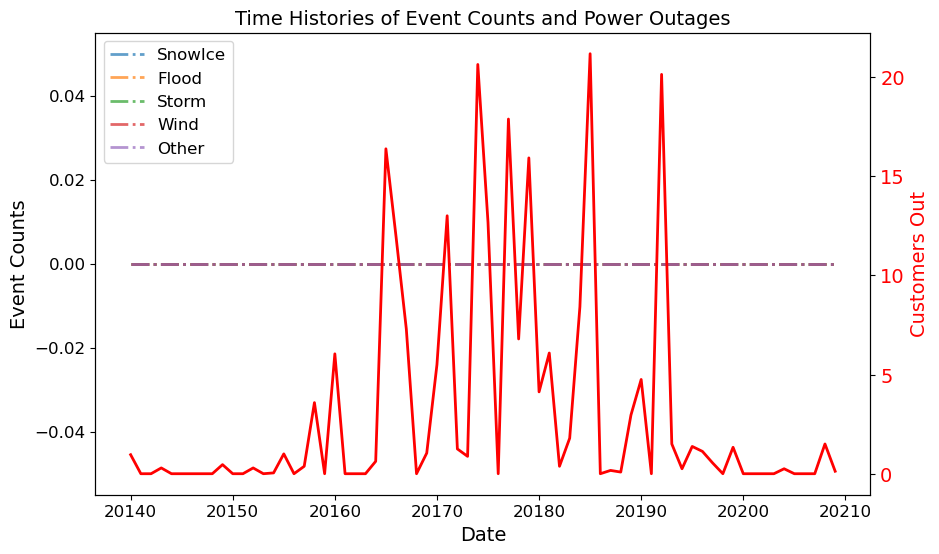

In [ ]:
plot_ts_events_power(df = eaglei_noaa_fips,
                     event_types = corr_list,
                     start_year = 2014,
                     start_month = 1,
                     start_day = 1,
                     end_year = 2021,
                     end_month = 12,
                     end_day = 31)

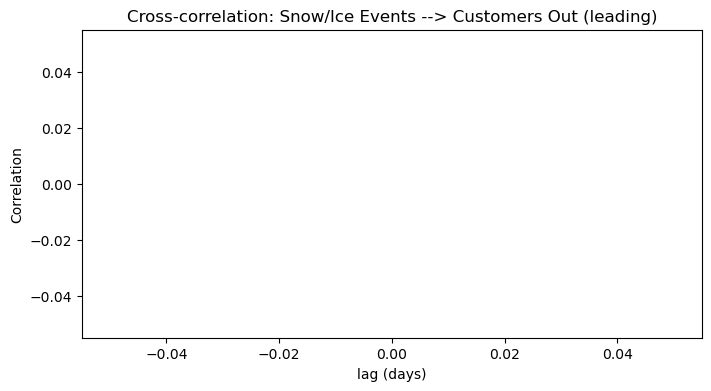

In [ ]:
power_outage = eaglei_noaa_fips['customers_out'].values
heat = eaglei_noaa_fips['event_count SnowIce'].values

lags = 12 # check up to +/- 12 days
cc_values = ccf(heat, power_outage, adjusted = False)

plt.figure(figsize=(8 ,4))
plt.bar(range(len(cc_values[:lags])),cc_values[:lags], width = 0.8)
plt.title('Cross-correlation: Snow/Ice Events --> Customers Out (leading)')
plt.xlabel('lag (days)')
plt.ylabel('Correlation')
plt.show()